# DAS Data Preprocessing and Visualization

**Author:** Shihao Yuan, Colorado School of Mines  
**Contact:** syuan@mines.edu

This notebook demonstrates basic preprocessing and visualization of DAS data using the **DASCore** library:

- Loading DAS data with DASCore
- Exploring data structure and metadata
- Preprocessing (detrending, filtering, tapering)
- Various visualization techniques
- Frequency analysis
- Saving processed data


Check the [DASCore documentation](https://dascore.org/) for more advanced features

## 1. Import Libraries


In [1]:
import os
import numpy as np
import dascore as dc
from dascore.units import Hz, m, s
from matplotlib import pyplot as plt

# Use inline plotting for Jupyter (change to %matplotlib qt for interactive plots)
%matplotlib inline

print(f"DASCore version: {dc.__version__}")


DASCore version: 0.1.12


## 2. Load DAS Data

We'll read the DAS data from the specified directory. DASCore uses a `Spool` object to manage data files.


In [2]:
# Change the path to your DAS data
data_path = './sample-data/decimator_2025-09-09_23.59.03_UTC_028858.raw'

# Create a spool from the directory
spool = dc.spool(data_path)

# Display spool information
print(f"Number of patches in spool: {len(spool)}")
print("Spool contents:")
print(spool)


Number of patches in spool: 1
Spool contents:
DASCore FileSpool 🧵 (1 Patch) Path: sample-data/decimator_2025-09-09_23.59.03_UTC_028858.raw


## 3. Explore Data Structure

Let's examine the first patch to understand the data structure and metadata.


In [3]:
# Get the first patch from the spool
patch = spool[0]

# Display patch information
print("Patch Attributes:")
print(patch.attrs)

# Display coordinate information
print("Coordinates:")
for coord_name in patch.dims:
    coord = patch.get_coord(coord_name)
    print(f"\n{coord_name}:")
    print(f"  Shape: {coord.shape}")
    print(f"  Min: {coord.min()}")
    print(f"  Max: {coord.max()}")
    print(f"  Units: {patch.attrs.coords[coord_name].units}")

# Display data array shape
print(f"\nData array shape: {patch.data.shape}")
print(f"  Data array dimensions: {patch.dims}")


Patch Attributes:
data_type='phase' data_category='' data_units=<Quantity(1, 'radian')> instrument_id='' acquisition_id='' tag='' station='' network='' history=() dims='time,distance' coords=<FrozenDict {'time': CoordSummary(dtype='datetime64', min=numpy.datetime64('2025-09-09T23:59:03.991282328'), max=numpy.datetime64('2025-09-10T00:00:03.989282328'), step=numpy.timedelta64(2000000,'ns'), units=<Quantity(1, 'second')>), 'distance': CoordSummary(dtype='float64', min=0.0, max=64970.85691165924, step=12.7619047164917, units=<Quantity(1, 'meter')>)}> gauge_length=20.738096237182617 gauge_length_units='m' gps_status=0
Coordinates:

time:
  Shape: (30000,)
  Min: 2025-09-09T23:59:03.991282328
  Max: 2025-09-10T00:00:03.989282328
  Units: 1 s

distance:
  Shape: (5092,)
  Min: 0.0
  Max: 64970.85691165924
  Units: 1 m

Data array shape: (30000, 5092)
  Data array dimensions: ('time', 'distance')


## 4. Visualize Raw Data

Let's create a quick visualization of the raw data to see what we're working with.


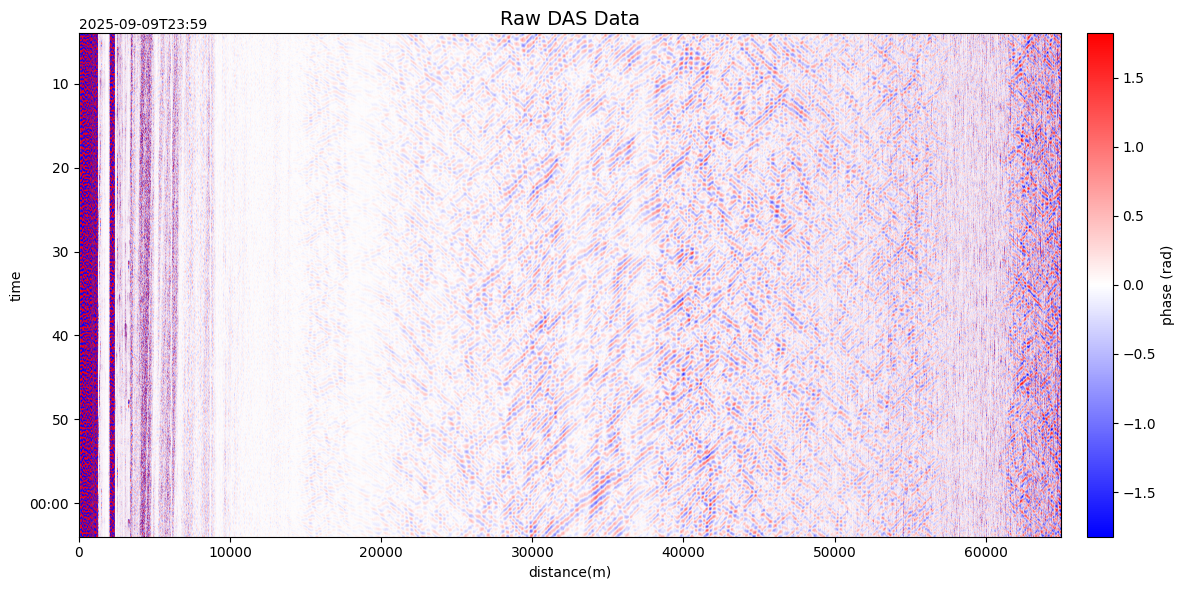

In [4]:
# Plot raw data as a waterfall plot
fig, ax = plt.subplots(figsize=(12, 6))
patch.viz.waterfall(ax=ax, scale=0.01)
ax.set_title('Raw DAS Data', fontsize=14)
plt.tight_layout()
plt.show()


## 5. Preprocess Data

Apply common preprocessing steps:
1. Set physical units (optional)
2. Detrend to remove linear trends
3. Taper to reduce edge effects
4. Apply bandpass filter
5. Decimate (optional) to reduce data size
6. Select specific distance/time ranges (optional)


In [ ]:
# Preprocessing pipeline
patch_processed = (
    patch
    .set_units(distance="m", time="s")         # Set physical units
    .detrend("time")                           # Remove linear trend along time axis
    .taper(time=0.01)                          # Apply 5% taper on time axis
    .pass_filter(time=(1 * Hz, 50 * Hz))       # Bandpass filter: 1-50 Hz
)

print(f"Processed patch shape: {patch_processed.data.shape}")


Processed patch shape: (30000, 5092)


### Optional: Decimation and Selection


In [6]:
# Decimate in time (downsample by factor of 10)
patch_processed = patch_processed.decimate(time=10)

# Select a specific distance range (e.g., channels 100-300)
# Use samples=True if selecting by index, or specify actual distance values
# patch_processed = patch_processed.select(distance=(100, 300), samples=True)
patch_processed = patch_processed.select(distance=(30000, 40000))

# Select a specific time window (e.g., first 120 seconds)
time_coord = patch_processed.get_coord('time')
time_start = time_coord[0]
time_end = time_start + np.timedelta64(120, 's')
patch_processed = patch_processed.select(time=(time_start, time_end))

print(f"After decimation/selection: {patch_processed.data.shape}")


After decimation/selection: (3000, 784)


## 6. Visualize Processed Data


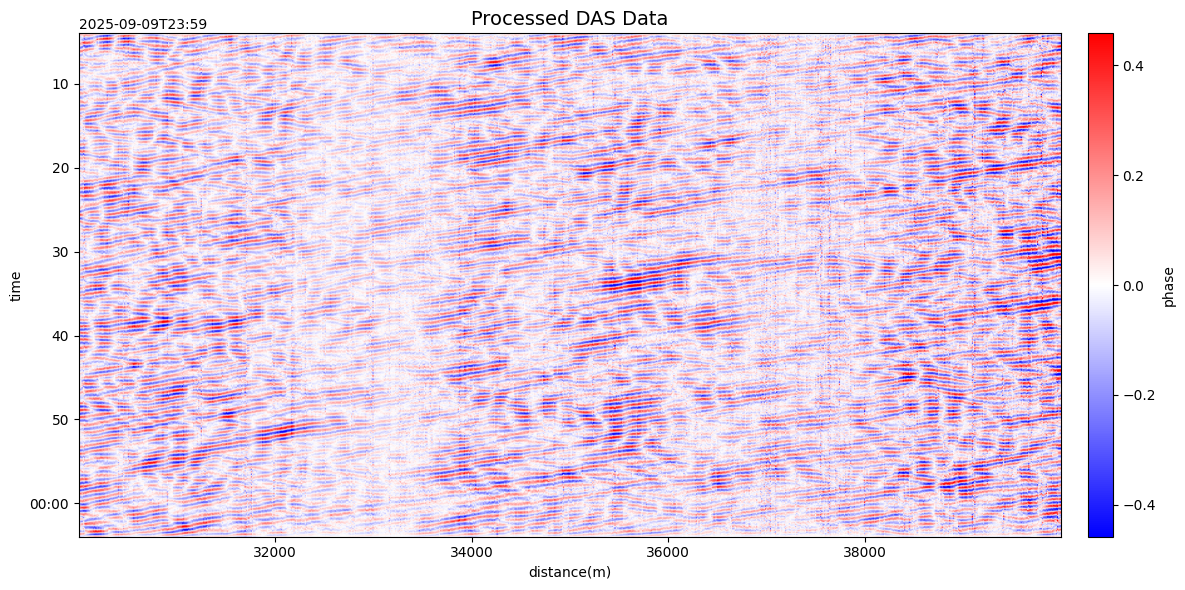

In [7]:
# Waterfall plot of processed data
fig, ax = plt.subplots(figsize=(12, 6))
patch_processed.viz.waterfall(ax=ax, scale=0.5)
ax.set_title('Processed DAS Data', fontsize=14)
plt.tight_layout()
plt.show()


## 7. Additional Visualizations

### 7.1 Compare Raw vs Processed


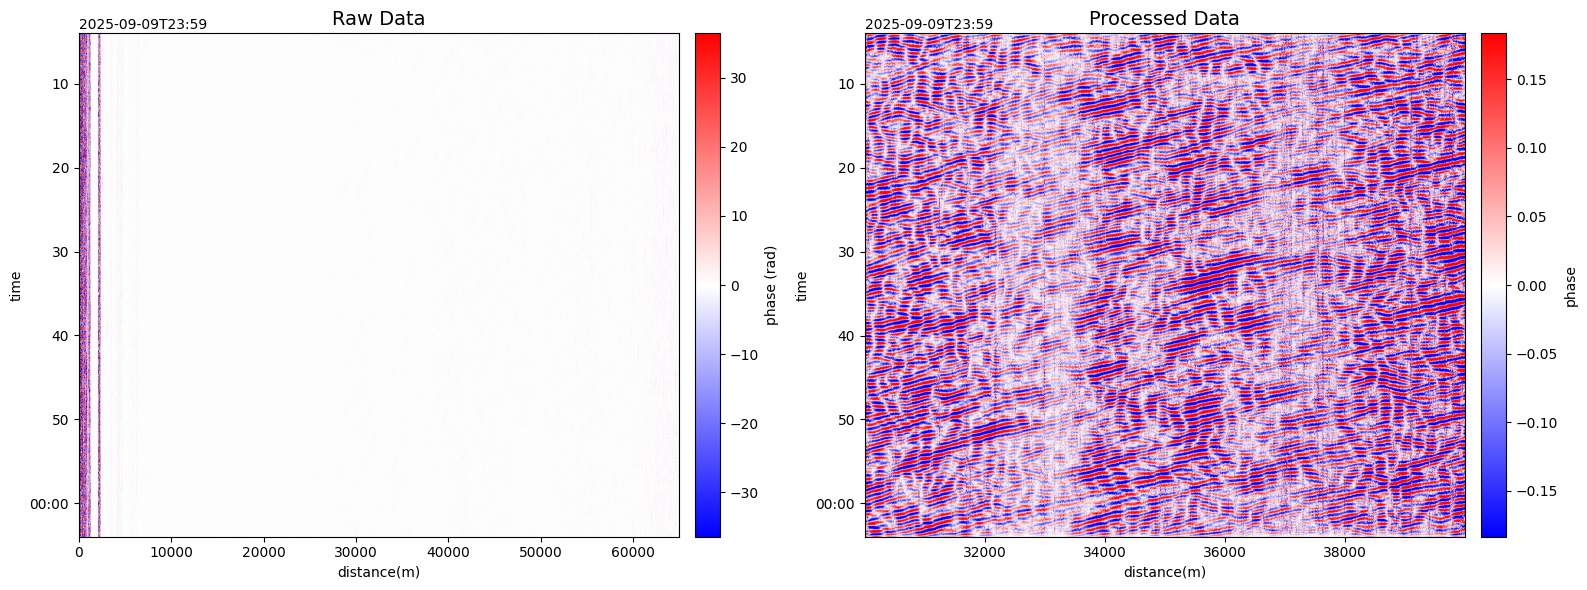

In [8]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

patch.viz.waterfall(ax=axes[0], scale=0.2)
axes[0].set_title('Raw Data', fontsize=14)

patch_processed.viz.waterfall(ax=axes[1], scale=0.2)
axes[1].set_title('Processed Data', fontsize=14)

plt.tight_layout()
plt.show()


### 7.2 Plot Single Trace


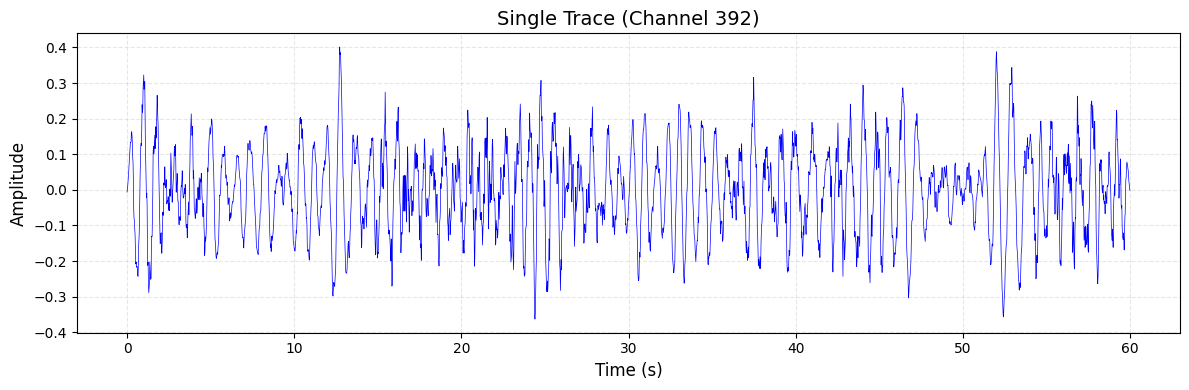

In [9]:
# Extract and plot a single trace (channel)
# Select middle channel
n_channels = patch_processed.data.shape[0] if 'distance' in patch_processed.dims[0] else patch_processed.data.shape[1]
mid_channel = n_channels // 2

# Get time axis
time_coord = patch_processed.get_coord('time')
time_seconds = (time_coord - time_coord[0]) / np.timedelta64(1, 's')

# Extract trace based on dimension order
if patch_processed.dims[0] == 'distance':
    trace = patch_processed.data[mid_channel, :]
else:
    trace = patch_processed.data[:, mid_channel]

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_seconds, trace, 'b-', linewidth=0.5)
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Amplitude', fontsize=12)
ax.set_title(f'Single Trace (Channel {mid_channel})', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


### 7.3 Frequency Analysis


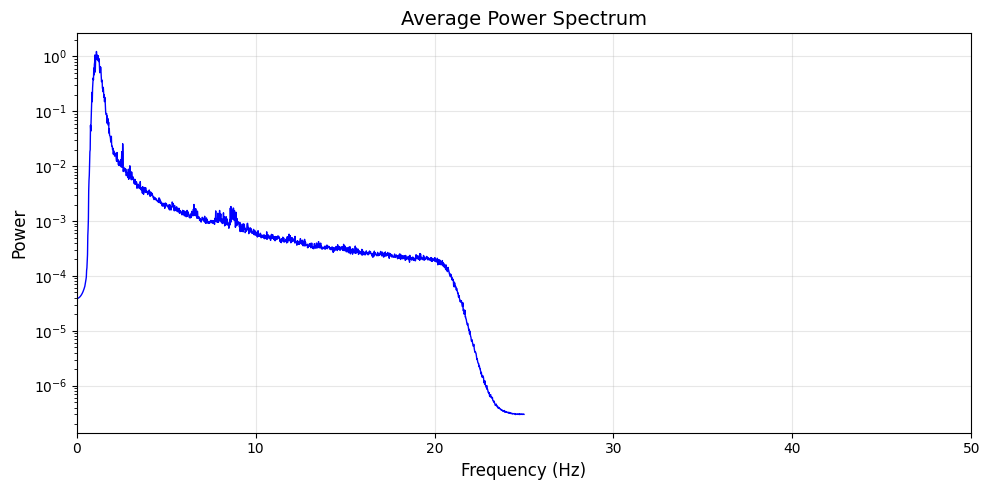

In [10]:
# Apply DFT (Discrete Fourier Transform) to analyze frequency content
patch_fft = patch_processed.dft(dim="time", real=True)

# Get frequency coordinate
freq_coord = patch_fft.get_coord('ft_time')

power_spectrum = np.abs(patch_fft.data)**2
avg_power = np.mean(power_spectrum, axis=0 if patch_fft.dims[0] == 'distance' else 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freq_coord, avg_power, 'b-', linewidth=1)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power', fontsize=12)
ax.set_title('Average Power Spectrum', fontsize=14)
ax.set_xlim(0, 50) 
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()


## 8. Save Processed Data

Save the processed patch for later use or further analysis.


In [11]:
# # Save processed data to HDF5 format
# output_path = './processed_data.h5'
# patch_processed.io.write(output_path, 'DASDAE')

# print(f"Processed data saved to: {output_path}")
